# Project Title:
### Implementing a Simple Linear Regression Model on a Housig Dataset


# Data-Set Overview
* This dataset contains housing and demographic details for different areas.
It is used to predict the median house value based on factors like location, number of rooms, population, and income.
* The ocean_proximity feature shows whether a property is located near the coastline.

# Features Description
* longitude (float): Represents the location's position from West to East.

* latitude (float): Represents the location's position from North to South.

* housing_median_age (int): The average age of houses in a specific area.

* total_rooms (int): The total number of rooms available in a block.

* total_bedrooms (int): The total number of bedrooms in a block.

* population (int): The total number of people living in a block.

* households (int): The total number of families or groups of people living in separate homes in a block.

* median_income (float): The average income of residents in a block (scaled value).

* median_house_value (float): The average price of houses in a block (this is the target variable for prediction).

* ocean_proximity (categorical): Shows how close a property is to the ocean (e.g., "NEAR BAY", "INLAND", "ISLAND", etc.).

##  Import Libraries

In [5]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings 
warnings.filterwarnings('ignore')


# Load the California Housing dataset

In [71]:
# Load the data
df = pd.read_csv('california_housing.csv')
print("First few rows:")
df.head(10)


First few rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
5,-122.25,37.85,52,919,213.0,413,193,4.0368,NEAR BAY,269700
6,-122.25,37.84,52,2535,489.0,1094,514,3.6591,NEAR BAY,299200
7,-122.25,37.84,52,3104,687.0,1157,647,3.1200,NEAR BAY,241400
8,-122.26,37.84,42,2555,665.0,1206,595,2.0804,NEAR BAY,226700
9,-122.25,37.84,52,3549,707.0,1551,714,3.6912,NEAR BAY,261100


# Information of dataset

In [74]:
 df.shape

(20640, 10)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


# Check the Column names

In [79]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'median_house_value'],
      dtype='object')

# Check the missing value

In [82]:

# Check for missing values
print("\
Missing values per column:")
print(df.isnull().sum())

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64


In [84]:
df.dropna(inplace=True)
print("droped missing value ")

droped missing value 


# Check the duplicate values

In [24]:
# check the duplicate values
df.duplicated().sum()


0

In [26]:
# if duplicate value in dataset
# Removing dutplicaes
df.drop_duplicates(inplace=True)


# Summary statistics

In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20433.0,-119.570689,2.003578,-124.3500,-121.8000,-118.4900,-118.010,-114.3100
latitude,20433.0,35.633221,2.136348,32.5400,33.9300,34.2600,37.720,41.9500
housing_median_age,20433.0,28.633094,12.591805,1.0000,18.0000,29.0000,37.000,52.0000
total_rooms,20433.0,2636.504233,2185.269567,2.0000,1450.0000,2127.0000,3143.000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.000,6445.0000
population,20433.0,1424.946949,1133.208490,3.0000,787.0000,1166.0000,1722.000,35682.0000
households,20433.0,499.433465,382.299226,1.0000,280.0000,409.0000,604.000,6082.0000
median_income,20433.0,3.871162,1.899291,0.4999,2.5637,3.5365,4.744,15.0001
median_house_value,20433.0,206864.413155,115435.667099,14999.0000,119500.0000,179700.0000,264700.000,500001.0000


# Correlation matrix 

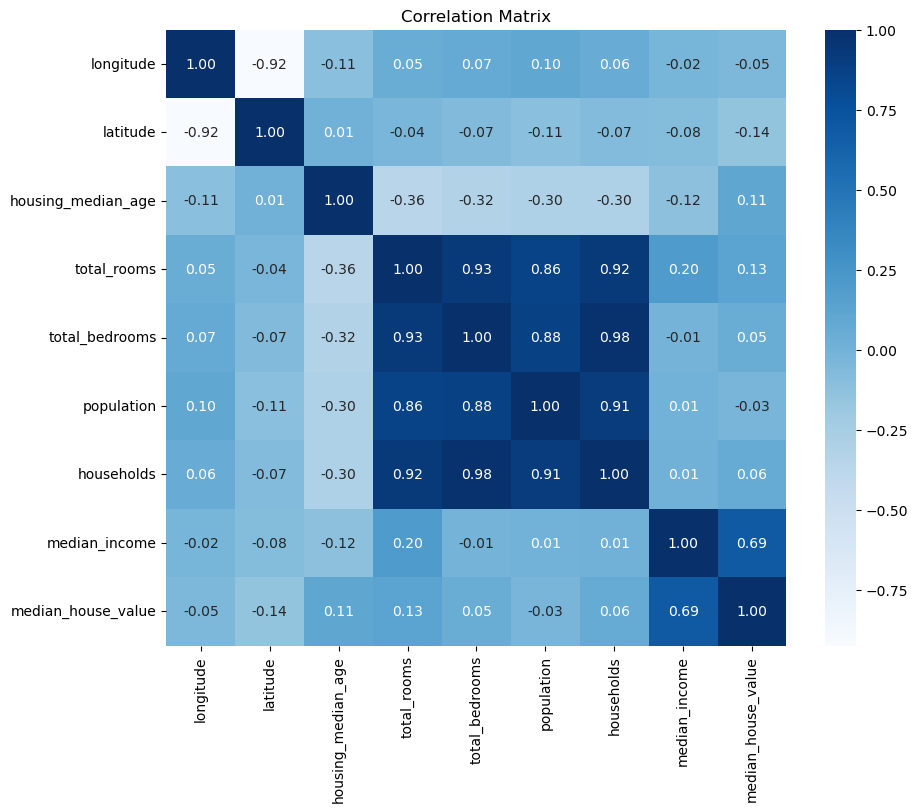

In [32]:
# Correlation matrix 
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)

# plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

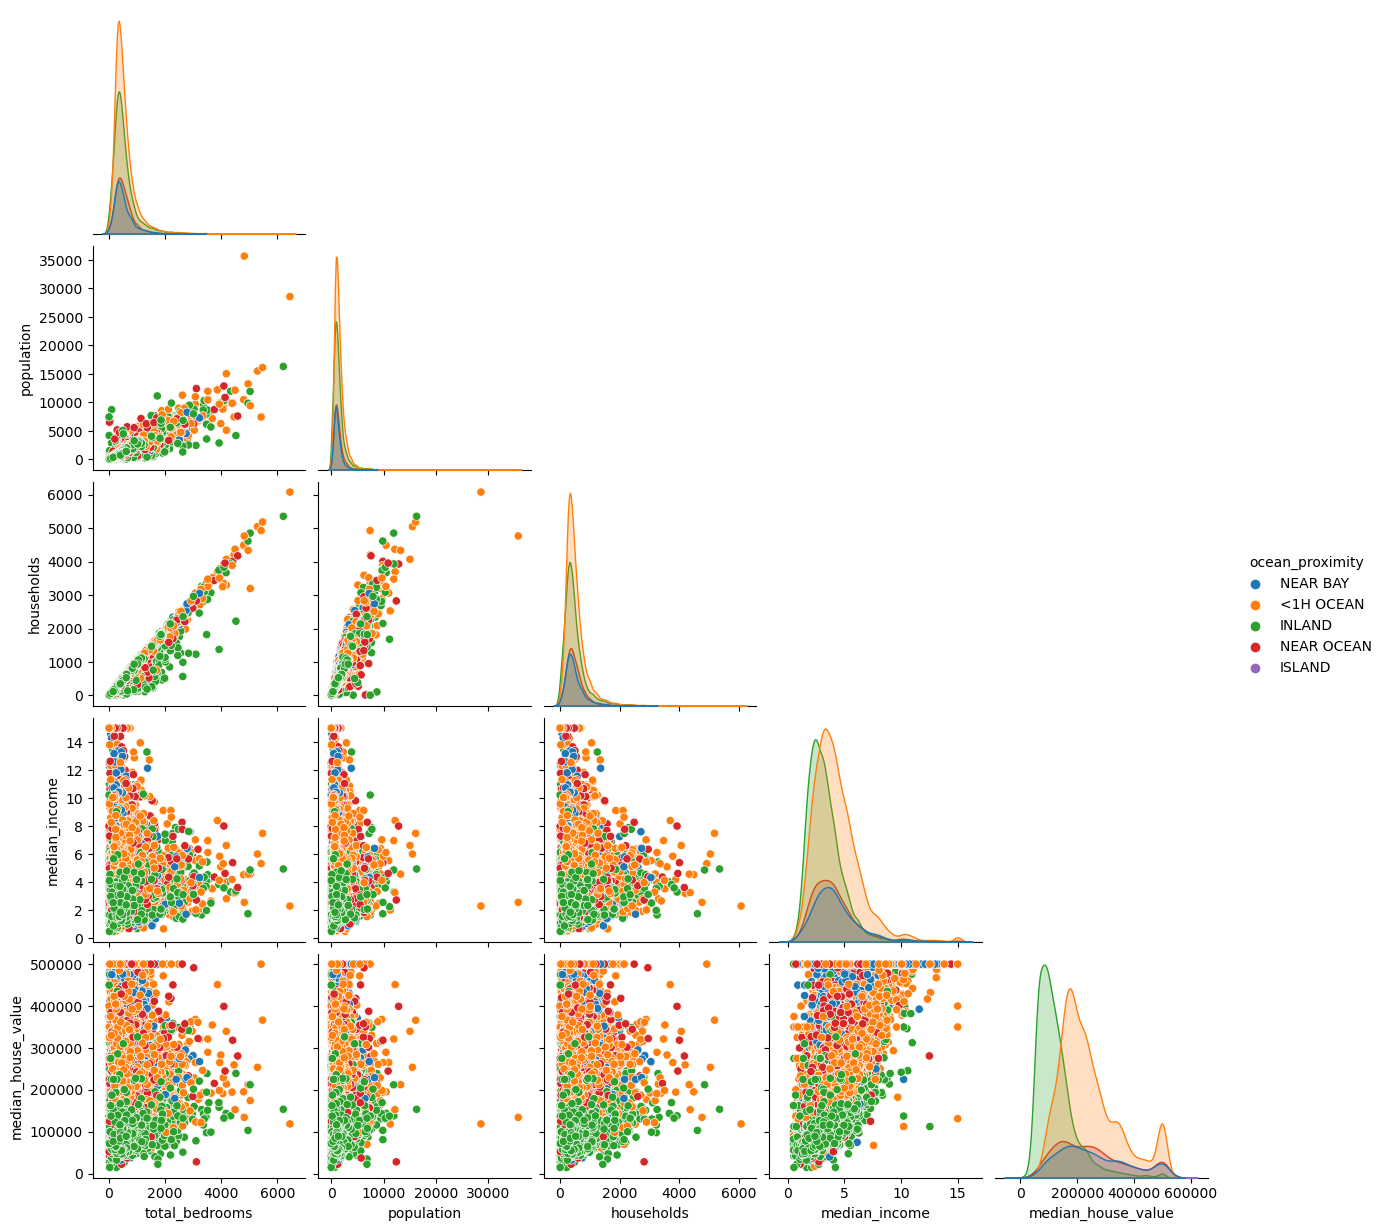

In [34]:
# Visualizing with pairplot
df=df.iloc[:,4:]
sns.pairplot(df, hue="ocean_proximity",corner=True)

# Normalize Numeric Columns

In [51]:
from sklearn.preprocessing import MinMaxScaler

# Normalize Numeric Columns
num_cols = df.select_dtypes(include="number").columns  # Select numeric columns
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,0.211155,0.567481,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,0.902266
1,0.212151,0.565356,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,0.708247
2,0.210159,0.564293,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,0.695051
3,0.209163,0.564293,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,0.672783
4,0.209163,0.564293,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,0.674638


# Define independent variables (X) and dependent variable (Y)

In [86]:
# Define independent variables (X) and dependent variable (Y)
X = df[['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 
        'population', 'households', 'median_income']]  # Features

y = df['median_house_value']  # Target variable

# Split Data into Training & Testing Sets

In [89]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train LinearRegression model

In [92]:

# Train the model
full_model = LinearRegression()
full_model.fit(X_train, y_train)

# Predictions
y_pred = full_model.predict(X_test)

# Model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")



Mean Squared Error (MSE): 4787247895.030929
R² Score: 0.6461446066126697


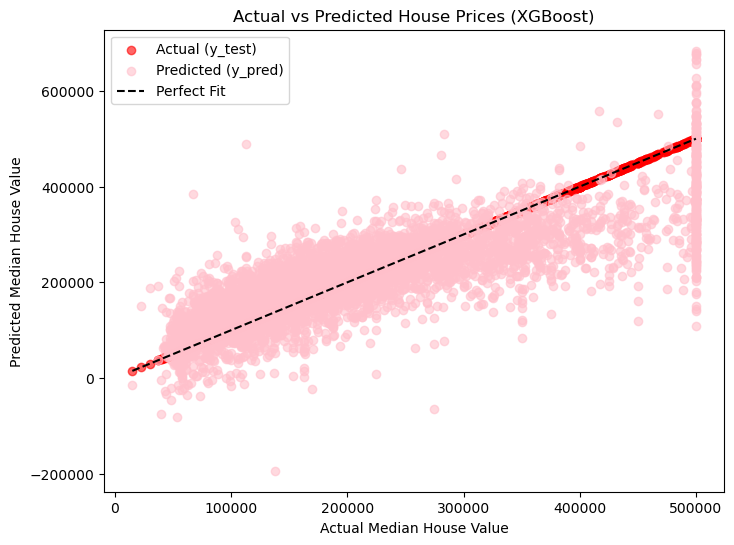

In [94]:
# Actual vs Predicted values
plt.figure(figsize=(8, 6))

# Scatter plot for actual values (y_test)
plt.scatter(y_test, y_test, color="red", alpha=0.6, label="Actual (y_test)")

# Scatter plot for predicted values (y_pred)
plt.scatter(y_test, y_pred, color="pink", alpha=0.6, label="Predicted (y_pred)")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--', label="Perfect Fit")

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted House Prices (XGBoost)")
plt.legend()  # Show legend
plt.show()

* RED Points → Represent actual values (y_test)
* PINK Points → Represent predicted values (y_pred)
* BLACK Dashed Line → Perfect prediction line (ideal case)

# Predict New Data Point

In [98]:

data_dict = {
    'longitude': [-122.23],
    'latitude': [37.88],
    'housing_median_age': [20],
    'total_rooms': [850],
    'total_bedrooms': [110],
    'population': [950],
    'households': [200],
    'median_income': [8.3252]
}

# Convert dictionary to DataFrame
new_data = pd.DataFrame(data_dict)



predicted_price = full_model.predict(new_data)

print(f"Predicted House Price: ${predicted_price[0]:,.2f}")

Predicted House Price: $364,227.97


# one more exmple for prediction

In [101]:
import pandas as pd

# Given data
data_dict = {
    'longitude': [-123.23],
    'latitude': [38.88],
    'housing_median_age': [40],
    'total_rooms': [900],
    'total_bedrooms': [150],
    'population': [350],
    'households': [140],
    'median_income': [8.3252]
}

# Convert to DataFrame
new_df = pd.DataFrame(data_dict)

# Predict house price
predicted_price = full_model.predict(new_df)

# Print result
print(f"If the given values are:\n{new_df.to_string(index=False)}\n\nThen the predicted house price is: ${predicted_price[0]:,.2f}")


If the given values are:
 longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income
   -123.23     38.88                  40          900             150         350         140         8.3252

Then the predicted house price is: $411,161.13
